<a href="https://colab.research.google.com/github/rizalrfli/PCVK_GANJIL-2026/blob/main/Week5_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

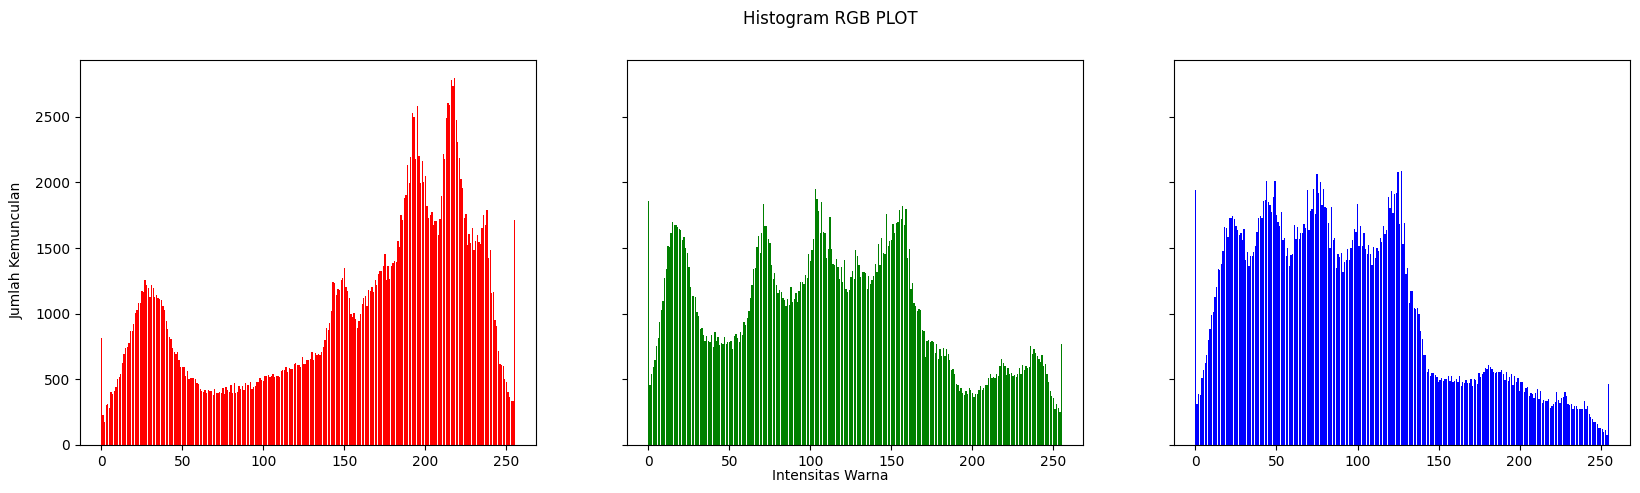

In [2]:
img = cv.imread('lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y  in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB PLOT')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation ='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color= 'blue')

In [3]:
b, g, r = cv.split(img)
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

In [4]:
import cv2 as cv, numpy as np, matplotlib.pyplot as plt
berkas = 'KTM2D.jpg' # Assuming 'CONTOH' is not defined and 'lena.jpg' is in the current directory
bgr = cv.imread(berkas)
# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

In [5]:
# cara 2: hanya kanal terang yang diekualisasi
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)
# varian setara pada ruang warna lain
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

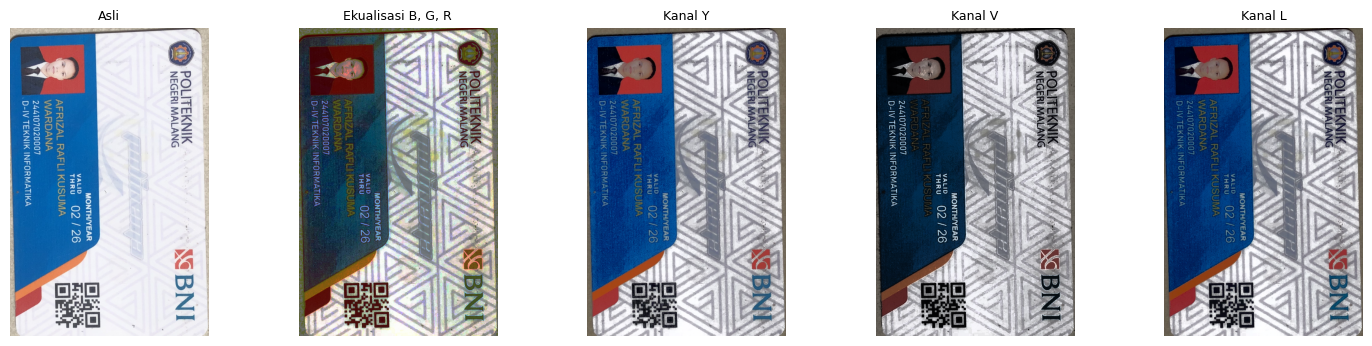

In [6]:
judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]
plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(t, fontsize=9) # Removed 'NIM' as it was not defined
    plt.axis('off')
plt.show()

In [7]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d) # Hue melingkar 0-179
    return d.mean()
print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
    cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            178.3
Ekualisasi B, G, R                63.15            129.9
Kanal Y                            2.01            132.4
Kanal V                            2.35            118.3
Kanal L                            6.86            124.8


# E-3 TUGAS PRAKTIKUM DITHERING

Bagian ini mengikuti Modul 5:
1. Floyd-Steinberg pada `lena.jpg` (verifikasi, `L = 2`) dan `KTM1b.jpg` (`L = PARAM['L']`).
2. Grayscale → Histogram Equalization → Floyd-Steinberg pada `lena_lc.jpg` dan `KTM1a.jpg`, serta dibandingkan dengan dithering langsung.

> **Catatan:** Jika `NIM`, `PARAM`, `CONTOH`, atau `BASE` sudah didefinisikan pada sel identitas, sel di bawah akan langsung memakainya. Jika belum, masukkan NIM saat diminta.


In [8]:
# ===== E-3 SETUP =====
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Ambil NIM dan PARAM dari sel identitas bila sudah ada.
if 'NIM' not in globals() or not str(NIM).strip():
    NIM = input('Masukkan NIM Anda: ').strip()

if 'PARAM' not in globals():
    N = int(str(NIM)[-3:])
    PARAM = {
        'bins': 2 ** ((N % 4) + 3),
        'clip': round(1.0 + (N % 5) * 0.5, 1),
        'tile': (N % 4) + 2,
        'L': 2 ** ((N % 3) + 1)
    }

L_KTM = int(PARAM['L'])
print('NIM      :', NIM)
print("PARAM['L']:", L_KTM)

def cari_berkas(nama, jenis='contoh'):
    # Mencari citra di CONTOH/BASE bila ada, lalu di current directory.
    kandidat = []
    if jenis == 'contoh' and 'CONTOH' in globals():
        kandidat.append(os.path.join(CONTOH, nama))
    if jenis == 'ktm' and 'BASE' in globals():
        kandidat.append(os.path.join(BASE, nama))
    kandidat += [
        nama,
        os.path.join('KTM1B.jpg', nama),
        os.path.join('KTM1B.jpg', nama),
    ]
    for p in kandidat:
        if p and os.path.exists(p):
            return p
    raise FileNotFoundError(
        f'{nama} tidak ditemukan. Upload citra atau pastikan CONTOH/BASE sudah benar.'
    )


Masukkan NIM Anda: 244107020007
NIM      : 244107020007
PARAM['L']: 4


In [9]:
def floyd_steinberg(gray, L=2):
    # Floyd-Steinberg untuk citra grayscale.
    if gray is None:
        raise ValueError('Citra tidak boleh None.')
    if gray.ndim != 2:
        raise ValueError('floyd_steinberg() membutuhkan citra grayscale.')
    if L < 2:
        raise ValueError('L minimal 2.')

    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]

            # Warna/level palet terdekat
            baru = np.round(lama / step) * step
            baru = np.clip(baru, 0, 255)
            img[y, x] = baru

            error = lama - baru

            # Distribusi error ke piksel yang belum diproses
            if x + 1 < W:
                img[y, x+1] = np.clip(img[y, x+1] + error * 7/16, 0, 255)

            if x > 0 and y + 1 < H:
                img[y+1, x-1] = np.clip(img[y+1, x-1] + error * 3/16, 0, 255)

            if y + 1 < H:
                img[y+1, x] = np.clip(img[y+1, x] + error * 5/16, 0, 255)

            if x + 1 < W and y + 1 < H:
                img[y+1, x+1] = np.clip(img[y+1, x+1] + error * 1/16, 0, 255)

    return np.rint(img).astype(np.uint8)


def floyd_steinberg_color(bgr, L=2):
    # Sesuai catatan modul: dijalankan terpisah pada kanal B, G, dan R.
    if bgr is None:
        raise ValueError('Citra tidak boleh None.')
    kanal = cv.split(bgr)
    hasil = [floyd_steinberg(k, L=L) for k in kanal]
    return cv.merge(hasil)


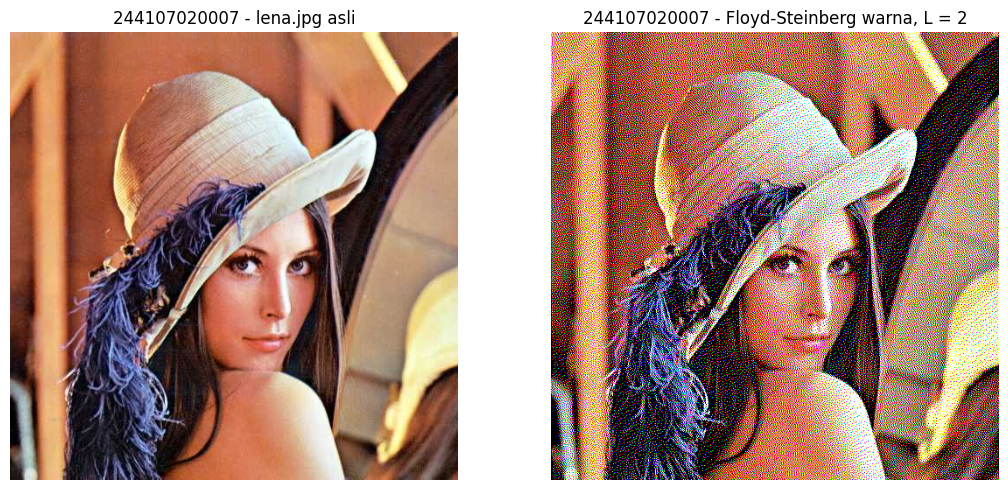

Level unik kanal B: [  0 255]
Level unik kanal G: [  0 255]
Level unik kanal R: [  0 255]


In [10]:
# E-3.1 Tahap 1: lena.jpg
path_lena = cari_berkas('lena.jpg', 'contoh')
lena_bgr = cv.imread(path_lena)

L_CONTOH = 2
lena_dither = floyd_steinberg_color(lena_bgr, L=L_CONTOH)

plt.figure(figsize=(11, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(lena_bgr, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - lena.jpg asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(lena_dither, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - Floyd-Steinberg warna, L = {L_CONTOH}')
plt.axis('off')

plt.tight_layout()
plt.show()

for idx, nama in enumerate(['B', 'G', 'R']):
    print(f'Level unik kanal {nama}:', np.unique(lena_dither[:, :, idx]))


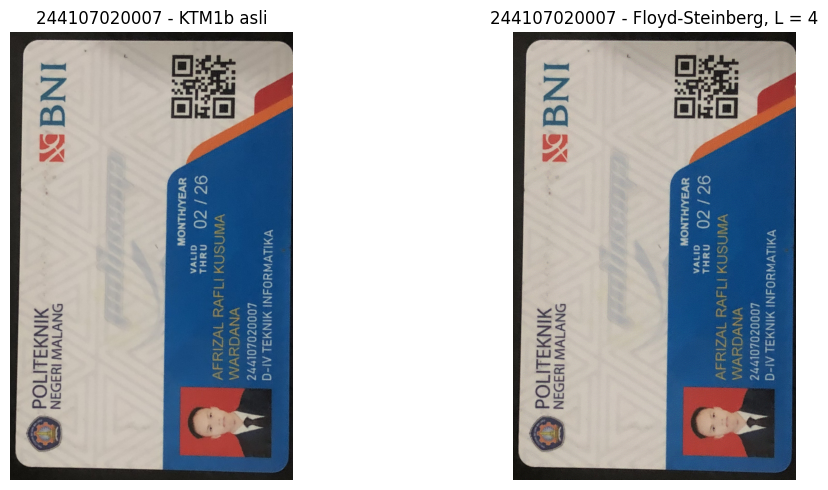

Jumlah level unik kanal B: 4 | nilai = [  0  85 170 255]
Jumlah level unik kanal G: 4 | nilai = [  0  85 170 255]
Jumlah level unik kanal R: 4 | nilai = [  0  85 170 255]


In [11]:
# E-3.1 Tahap 2: KTM1b.jpg
path_ktm1b = cari_berkas('KTM1B.jpg')
ktm1b_bgr = cv.imread(path_ktm1b)
ktm1b_dither = floyd_steinberg_color(ktm1b_bgr, L=L_KTM)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(ktm1b_bgr, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - KTM1b asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(ktm1b_dither, cv.COLOR_BGR2RGB))
plt.title(f"{NIM} - Floyd-Steinberg, L = {L_KTM}")
plt.axis('off')

plt.tight_layout()
plt.show()

for idx, nama in enumerate(['B', 'G', 'R']):
    unik = np.unique(ktm1b_dither[:, :, idx])
    print(f'Jumlah level unik kanal {nama}: {len(unik)} | nilai = {unik}')


In [12]:
from numba import jit

@jit(nopython=True)
def floyd_steinberg_optimized(gray, L=2):
    # Floyd-Steinberg untuk citra grayscale.
    if gray is None:
        raise ValueError('Citra tidak boleh None.')
    if gray.ndim != 2:
        raise ValueError('floyd_steinberg() membutuhkan citra grayscale.')
    if L < 2:
        raise ValueError('L minimal 2.')

    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]

            # Warna/level palet terdekat
            baru = np.round(lama / step) * step
            # Using min/max for scalar clipping instead of np.clip
            baru = max(0.0, min(baru, 255.0)) # Ensure float literals
            img[y, x] = baru

            error = lama - baru

            # Distribusi error ke piksel yang belum diproses
            if x + 1 < W:
                # Using min/max for scalar clipping instead of np.clip
                img[y, x+1] = max(0.0, min(img[y, x+1] + error * 7/16, 255.0))

            if x > 0 and y + 1 < H:
                # Using min/max for scalar clipping instead of np.clip
                img[y+1, x-1] = max(0.0, min(img[y+1, x-1] + error * 3/16, 255.0))

            if y + 1 < H:
                # Using min/max for scalar clipping instead of np.clip
                img[y+1, x] = max(0.0, min(img[y+1, x] + error * 5/16, 255.0))

            if x + 1 < W and y + 1 < H:
                # Using min/max for scalar clipping instead of np.clip
                img[y+1, x+1] = max(0.0, min(img[y+1, x+1] + error * 1/16, 255.0))

    return np.rint(img).astype(np.uint8)

def floyd_steinberg_color_optimized(bgr, L=2):
    if bgr is None:
        raise ValueError('Citra tidak boleh None.')
    kanal = cv.split(bgr)
    hasil = [floyd_steinberg_optimized(k, L=L) for k in kanal]
    return cv.merge(hasil)

print("Optimized Floyd-Steinberg functions defined.")

Optimized Floyd-Steinberg functions defined.


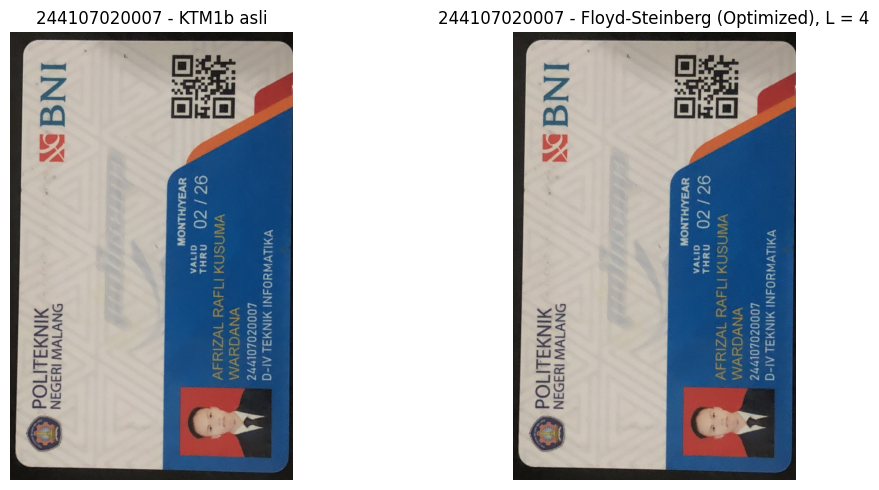

Jumlah level unik kanal B: 4 | nilai = [  0  85 170 255]
Jumlah level unik kanal G: 4 | nilai = [  0  85 170 255]
Jumlah level unik kanal R: 4 | nilai = [  0  85 170 255]


In [13]:
# E-3.1 Tahap 2: KTM1b.jpg (Optimized)
path_ktm1b = cari_berkas('KTM1B.jpg')
ktm1b_bgr = cv.imread(path_ktm1b)
ktm1b_dither_optimized = floyd_steinberg_color_optimized(ktm1b_bgr, L=L_KTM)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(ktm1b_bgr, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - KTM1b asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(ktm1b_dither_optimized, cv.COLOR_BGR2RGB))
plt.title(f"{NIM} - Floyd-Steinberg (Optimized), L = {L_KTM}")
plt.axis('off')

plt.tight_layout()
plt.show()

for idx, nama in enumerate(['B', 'G', 'R']):
    unik = np.unique(ktm1b_dither_optimized[:, :, idx])
    print(f'Jumlah level unik kanal {nama}: {len(unik)} | nilai = {unik}')

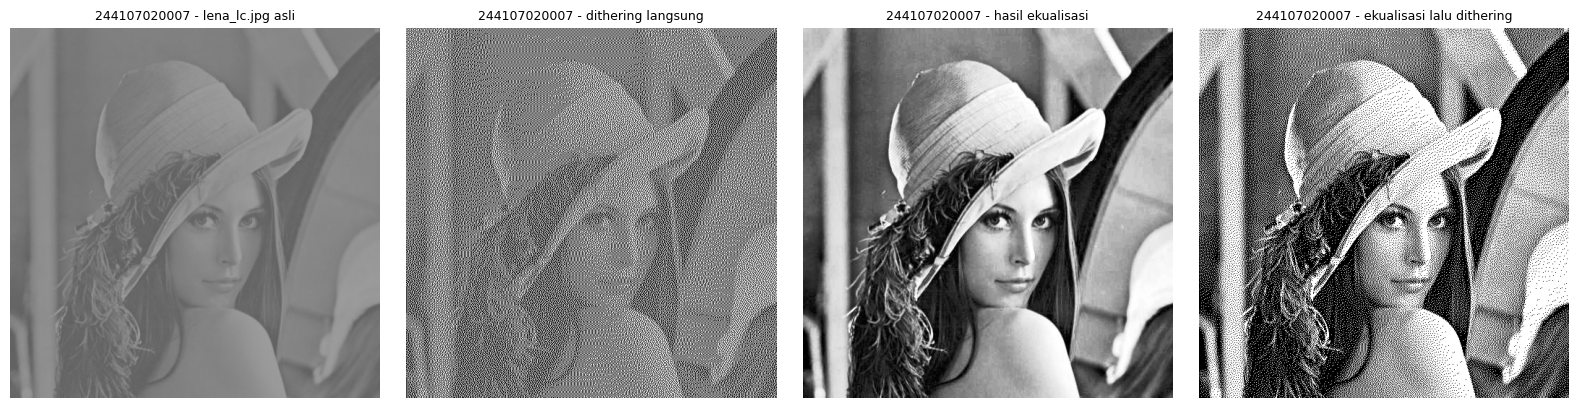

In [14]:
# E-3.2 Tahap 1: lena_lc.jpg
path_lena_lc = cari_berkas('lena_lc.jpg', 'contoh')
lena_lc = cv.imread(path_lena_lc, cv.IMREAD_GRAYSCALE)

lena_lc_dither_langsung = floyd_steinberg(lena_lc, L=2)
lena_lc_eq = cv.equalizeHist(lena_lc)
lena_lc_eq_dither = floyd_steinberg(lena_lc_eq, L=2)

plt.figure(figsize=(16, 4))

data = [
    (lena_lc, 'lena_lc.jpg asli'),
    (lena_lc_dither_langsung, 'dithering langsung'),
    (lena_lc_eq, 'hasil ekualisasi'),
    (lena_lc_eq_dither, 'ekualisasi lalu dithering'),
]

for i, (img, judul) in enumerate(data, 1):
    plt.subplot(1, 4, i)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(f'{NIM} - {judul}', fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()


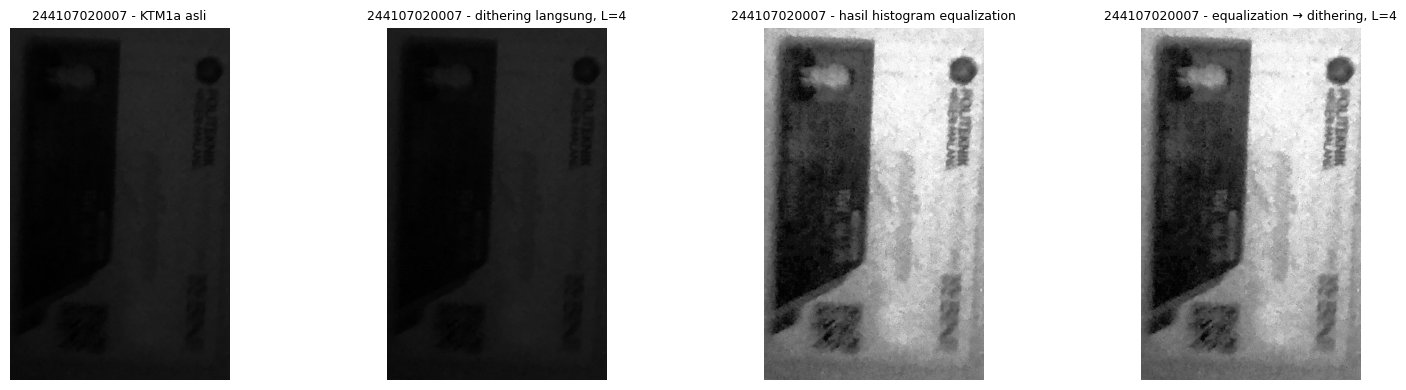

Rerata / standar deviasi intensitas:
Asli                  : mean=20.10, std=11.71
Equalization          : mean=130.99, std=73.20
Dithering langsung    : mean=20.19, std=36.18
Equalization+dithering: mean=130.98, std=80.71


In [15]:
# E-3.2 Tahap 2: KTM1a.jpg
path_ktm1a = cari_berkas('KTM1A.jpg', 'ktm')
ktm1a = cv.imread(path_ktm1a, cv.IMREAD_GRAYSCALE)

# A. Dithering langsung
ktm1a_dither_langsung = floyd_steinberg(ktm1a, L=L_KTM)

# B. Histogram Equalization lalu Dithering
ktm1a_eq = cv.equalizeHist(ktm1a)
ktm1a_eq_dither = floyd_steinberg(ktm1a_eq, L=L_KTM)

plt.figure(figsize=(16, 4))

data_ktm = [
    (ktm1a, 'KTM1a asli'),
    (ktm1a_dither_langsung, f'dithering langsung, L={L_KTM}'),
    (ktm1a_eq, 'hasil histogram equalization'),
    (ktm1a_eq_dither, f'equalization → dithering, L={L_KTM}'),
]

for i, (img, judul) in enumerate(data_ktm, 1):
    plt.subplot(1, 4, i)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(f'{NIM} - {judul}', fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

print('Rerata / standar deviasi intensitas:')
print(f'Asli                  : mean={ktm1a.mean():.2f}, std={ktm1a.std():.2f}')
print(f'Equalization          : mean={ktm1a_eq.mean():.2f}, std={ktm1a_eq.std():.2f}')
print(f'Dithering langsung    : mean={ktm1a_dither_langsung.mean():.2f}, std={ktm1a_dither_langsung.std():.2f}')
print(f'Equalization+dithering: mean={ktm1a_eq_dither.mean():.2f}, std={ktm1a_eq_dither.std():.2f}')


# PERTANYAAN PRAKTIKUM E-2

## E-2 Nomor 1 — Ekualisasi Global KTM1a


Selisih maksimum manual vs cv.equalizeHist = 1
PSNR asli vs hasil equalization = 6.07 dB


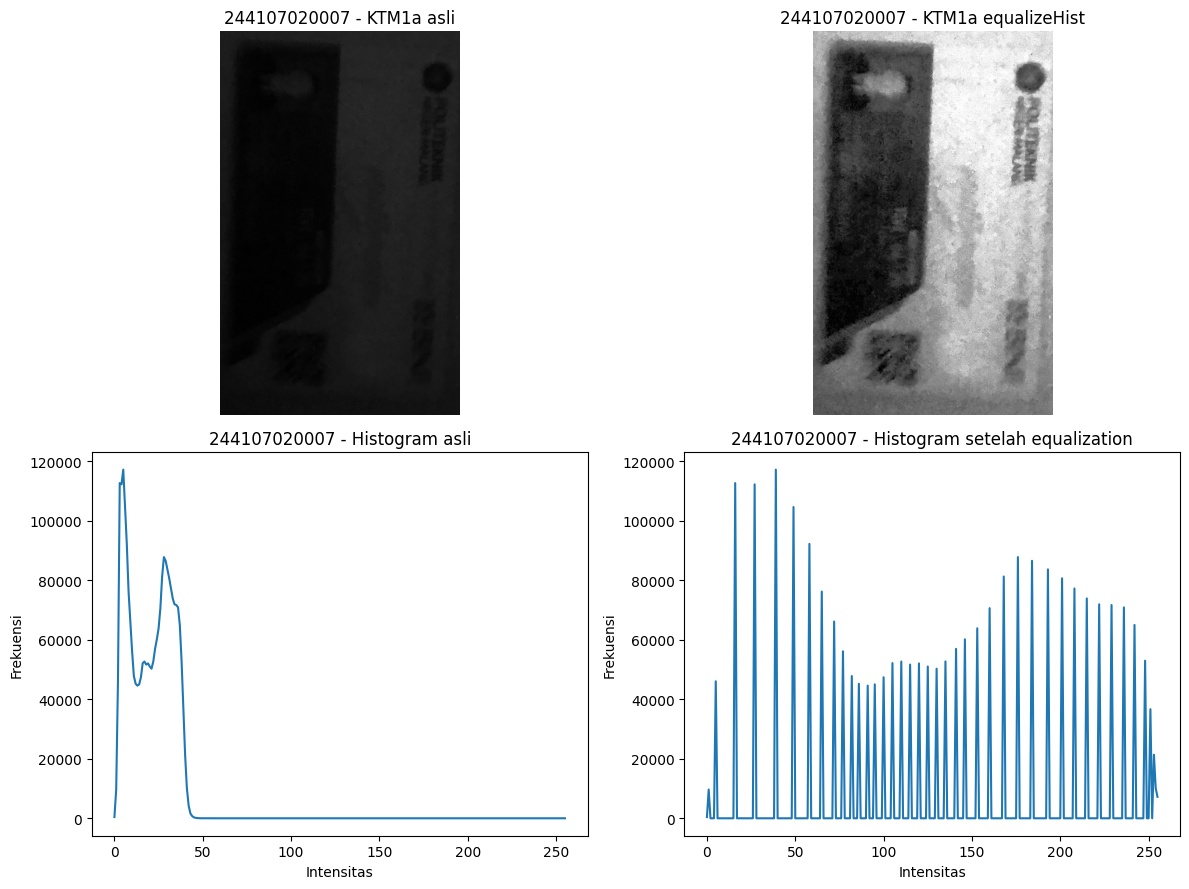

In [19]:
def equalize_manual(image):
    # Ensure image is grayscale
    if image.ndim > 2:
        image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

    # Calculate histogram
    hist = cv.calcHist([image], [0], None, [256], [0, 256])

    # Calculate cumulative distribution function (CDF)
    cdf = hist.cumsum()

    # Normalize CDF
    # Find the minimum non-zero CDF value
    cdf_m = np.ma.masked_equal(cdf, 0)
    # Check if there are any non-zero values in cdf_m to prevent division by zero or NaN results
    if cdf_m.count() > 0:
        cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    else:
        # If all cdf values are 0 (e.g., a completely black image), no equalization is possible.
        # In this edge case, return a black image or the original unchanged.
        cdf_m = np.zeros_like(cdf) # Or simply return the original image if no change is desired

    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')

    # Apply the equalization using the CDF as a lookup table
    equalized_image = cdf_final[image]
    return equalized_image

ktm1a = cv.imread('KTM1A.jpg', cv.IMREAD_GRAYSCALE)

eq_manual = equalize_manual(ktm1a)
eq_cv = cv.equalizeHist(ktm1a)

selisih_max = int(np.max(np.abs(eq_manual.astype(np.int16) - eq_cv.astype(np.int16))))
psnr = cv.PSNR(ktm1a, eq_cv)

print('Selisih maksimum manual vs cv.equalizeHist =', selisih_max)
print('PSNR asli vs hasil equalization = %.2f dB' % psnr)

h_asli = cv.calcHist([ktm1a], [0], None, [256], [0, 256]).ravel()
h_eq = cv.calcHist([eq_cv], [0], None, [256], [0, 256]).ravel()

fig, ax = plt.subplots(2, 2, figsize=(12, 9))

ax[0, 0].imshow(ktm1a, cmap='gray', vmin=0, vmax=255)
ax[0, 0].set_title(f'{NIM} - KTM1a asli')
ax[0, 0].axis('off')

ax[0, 1].imshow(eq_cv, cmap='gray', vmin=0, vmax=255)
ax[0, 1].set_title(f'{NIM} - KTM1a equalizeHist')
ax[0, 1].axis('off')

ax[1, 0].plot(h_asli)
ax[1, 0].set_title(f'{NIM} - Histogram asli')
ax[1, 0].set_xlabel('Intensitas')
ax[1, 0].set_ylabel('Frekuensi')

ax[1, 1].plot(h_eq)
ax[1, 1].set_title(f'{NIM} - Histogram setelah equalization')
ax[1, 1].set_xlabel('Intensitas')
ax[1, 1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

## E-2 Nomor 2 — Ekualisasi Lokal CLAHE pada KTM1a


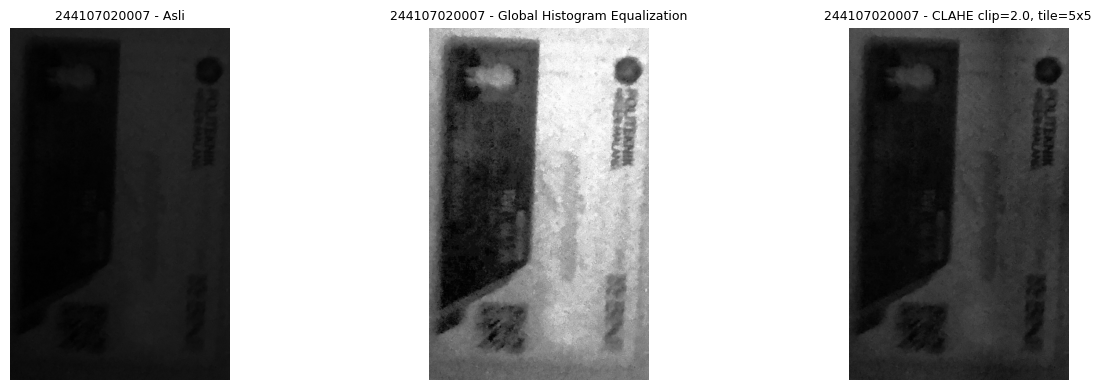

Asli     : mean=20.10 std=11.71
Global HE: mean=130.99 std=73.20
CLAHE    : mean=40.93 std=21.50


In [20]:
# E-2 No. 2a
global_he = cv.equalizeHist(ktm1a)

clahe_utama = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)
clahe_img = clahe_utama.apply(ktm1a)

plt.figure(figsize=(14, 4))
for i, (img, judul) in enumerate([
    (ktm1a, 'Asli'),
    (global_he, 'Global Histogram Equalization'),
    (clahe_img, f"CLAHE clip={PARAM['clip']}, tile={PARAM['tile']}x{PARAM['tile']}")
], 1):
    plt.subplot(1, 3, i)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(f'{NIM} - {judul}', fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

print('Asli     : mean=%.2f std=%.2f' % (ktm1a.mean(), ktm1a.std()))
print('Global HE: mean=%.2f std=%.2f' % (global_he.mean(), global_he.std()))
print('CLAHE    : mean=%.2f std=%.2f' % (clahe_img.mean(), clahe_img.std()))


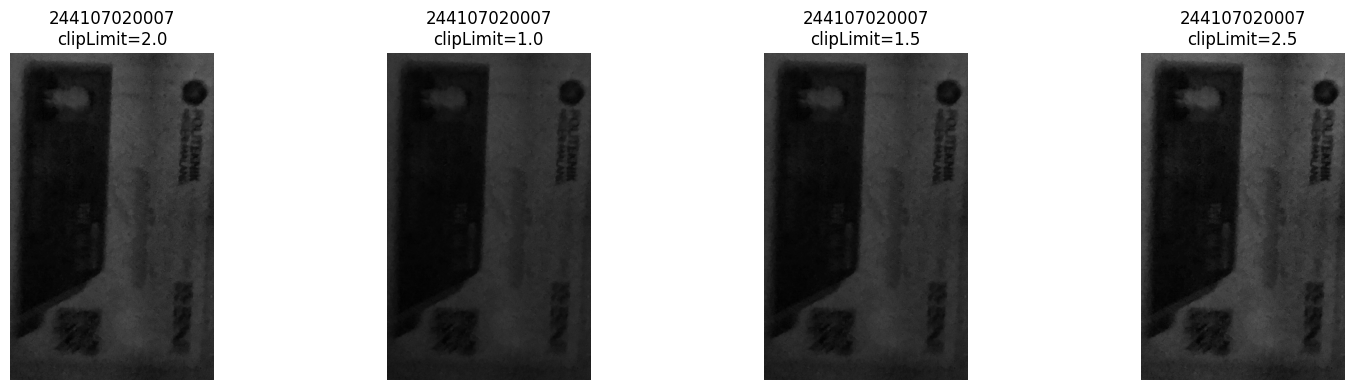

clipLimit    mean         std          Laplacian variance
2.00         40.93        21.50        33.74             
1.00         31.63        16.72        15.75             
1.50         36.44        19.18        24.29             
2.50         45.13        23.74        44.94             


In [21]:
# E-2 No. 2b: tiga clipLimit lain di sekitar nilai pribadi
clip_utama = float(PARAM['clip'])
clip_lain = sorted(set([
    max(0.5, clip_utama - 1.0),
    max(0.5, clip_utama - 0.5),
    clip_utama + 0.5
]))

clip_semua = [clip_utama] + clip_lain

hasil_clip = []
for cl in clip_semua:
    op = cv.createCLAHE(
        clipLimit=float(cl),
        tileGridSize=(PARAM['tile'], PARAM['tile'])
    )
    hasil = op.apply(ktm1a)
    hasil_clip.append((cl, hasil))

plt.figure(figsize=(4 * len(hasil_clip), 4))
for i, (cl, hasil) in enumerate(hasil_clip, 1):
    plt.subplot(1, len(hasil_clip), i)
    plt.imshow(hasil, cmap='gray', vmin=0, vmax=255)
    plt.title(f'{NIM}\nclipLimit={cl}')
    plt.axis('off')
plt.tight_layout()
plt.show()

print('%-12s %-12s %-12s %-18s' % ('clipLimit', 'mean', 'std', 'Laplacian variance'))
for cl, hasil in hasil_clip:
    lap_var = cv.Laplacian(hasil, cv.CV_64F).var()
    print('%-12.2f %-12.2f %-12.2f %-18.2f' %
          (cl, hasil.mean(), hasil.std(), lap_var))
